In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [31]:
df = pd.read_csv('./data/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [30]:
# CustomerID 제거, 성별 인코딩
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

X = df[features].values

In [28]:
# Gender 다시 0/1로 복구
df = pd.read_csv('./data/Mall_Customers.csv')

df['Gender'] = (df['Gender'] == 'Male').astype(int)

In [32]:
# StandardScaler로 x 스케일링
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DataFrame 형태로 보기
import pandas as pd
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

X_scaled_df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [42]:
X_scaled_df

,Age,Annual Income (k$),Spending Score (1-100),Gender
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405
...,...,...,...,...
195,-0.276302,2.268791,1.118061,-0.886405
196,0.441365,2.497807,-0.861839,-0.886405
197,-0.491602,2.497807,0.923953,1.128152
198,-0.491602,2.917671,-1.250054,1.128152


In [43]:
# 1️⃣ Gender는 0/1 유지
df['Gender'] = df['Gender'].round().astype(int)

# 2️⃣ 연속형 변수만 선택
num_features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])

# 3️⃣ Gender는 그대로 두고 최종 X 만들기
columns = num_features + ['Gender']
X = df[columns].values

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,-1.424569,-1.738999,-0.434801
1,2,1,-1.281035,-1.738999,1.195704
2,3,0,-1.352802,-1.700830,-1.715913
3,4,0,-1.137502,-1.700830,1.040418
4,5,0,-0.563369,-1.662660,-0.395980


In [44]:
# PCA : 2개의 주성분으로 압축
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# DataFrame으로 보기
X_pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
X_pca_df.head()

,PC1,PC2
0,-0.406383,-0.520714
1,-1.427673,-0.367310
2,0.050761,-1.894068
3,-1.694513,-1.631908
4,-0.313108,-1.810483


In [45]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Explained Variance:", pca.explained_variance_ratio_.sum())

Explained Variance Ratio: [0.33690046 0.26230645]
Total Explained Variance: 0.5992069019819847


In [ ]:
# KMEANS 클러스터링 


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

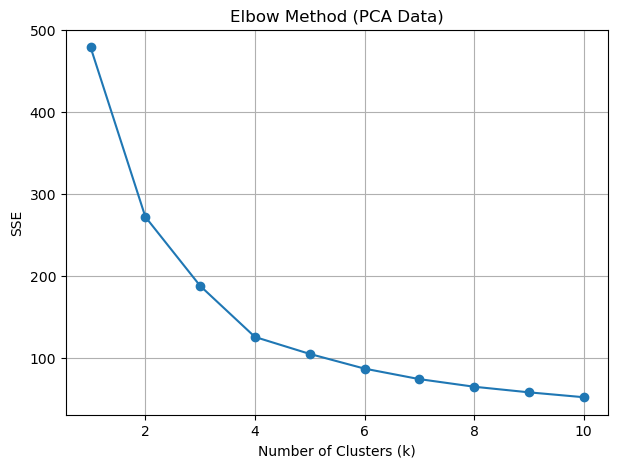

In [46]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sse = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    km.fit(X_pca)
    sse.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(k_range, sse, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE')
plt.title('Elbow Method (PCA Data)')
plt.grid(True)
plt.show()

In [47]:
kmeans = KMeans(n_clusters=4, random_state=0, n_init=10)
clusters = kmeans.fit_predict(X_pca)

# 결과 저장
X_pca_df['cluster'] = clusters

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [ ]:
# KMeans 클러스터링 결과 시각화

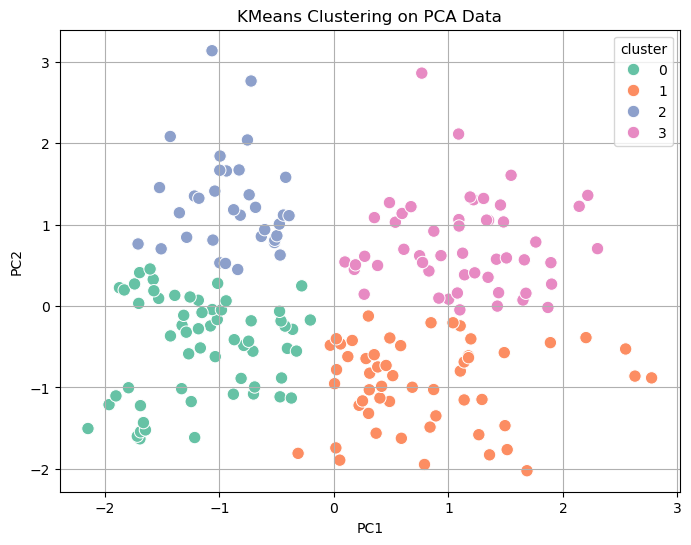

In [48]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=X_pca_df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set2',
    s=80
)

plt.title('KMeans Clustering on PCA Data')
plt.grid(True)
plt.show()

# 젠더 제외하고 진행하기

Explained Variance Ratio: [0.44266167 0.33308378]
Total Explained Variance: 0.7757454566976747


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

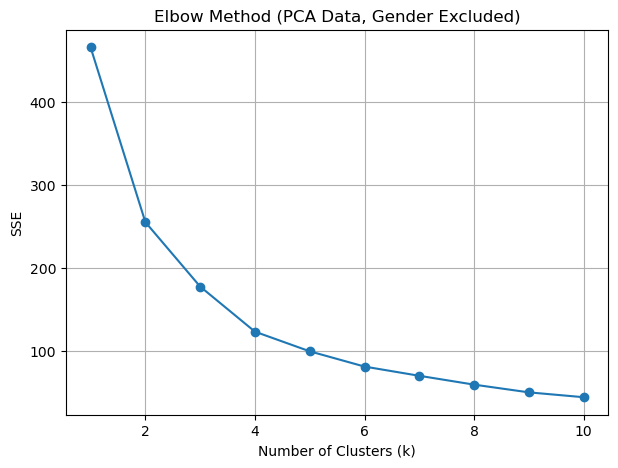

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


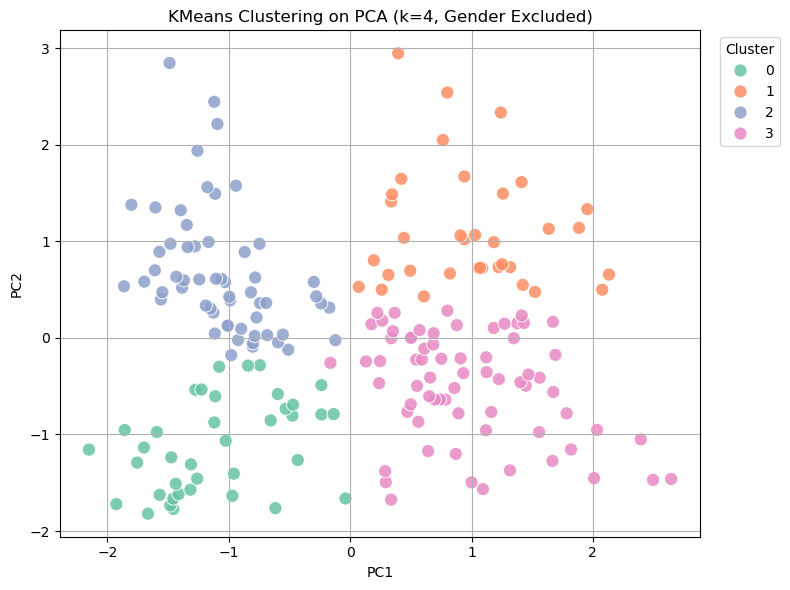

In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Gender 제외: 연속형 3개만 사용
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].values

# 2) 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3) PCA 2차원
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Explained Variance:", pca.explained_variance_ratio_.sum())

# 4) 엘보우 (PCA 데이터 기준)
sse = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    km.fit(X_pca)
    sse.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(list(k_range), sse, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE')
plt.title('Elbow Method (PCA Data, Gender Excluded)')
plt.grid(True)
plt.show()

# 5) KMeans 
k = 4
kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
pca_df['cluster'] = kmeans.fit_predict(X_pca)

# 6) 시각화 (seaborn)
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set2',
    s=90,
    alpha=0.85
)
plt.title(f'KMeans Clustering on PCA (k={k}, Gender Excluded)')
plt.grid(True)
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [51]:
cluster_result = df.copy()
cluster_result['cluster'] = pca_df['cluster']

cluster_summary = cluster_result.groupby('cluster')[['Age',
                                                      'Annual Income (k$)',
                                                      'Spending Score (1-100)']].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,
0,-0.950531,-1.066012,0.671613
1,0.203510,1.056094,-1.277784
2,-0.635135,0.707135,0.798787
3,0.954133,-0.543024,-0.393167


| 클러스터 | 특징      | 전략       |
| ---- | ------- | -------- |
| 0    | 젊은 고소비  | 트렌드 마케팅  |
| 1    | 고소득 저소비 | 전환 전략    |
| 2    | 고소득 고소비 | VIP 관리   |
| 3    | 저소득 저소비 | 비용 효율 운영 |


# 실루엣 점수

In [52]:
from sklearn.metrics import silhouette_score, silhouette_samples
import numpy as np

# 이미 k=4로 클러스터링 했다고 가정
labels = pca_df['cluster']

sil_score = silhouette_score(X_pca, labels)
print("Silhouette Score:", round(sil_score, 4))

Silhouette Score: 0.4209


In [53]:
sample_silhouette = silhouette_samples(X_pca, labels)
pca_df['silhouette'] = sample_silhouette

cluster_silhouette = pca_df.groupby('cluster')['silhouette'].mean()
cluster_silhouette

cluster
0    0.458953
1    0.386279
2    0.469848
3    0.376443
Name: silhouette, dtype: float64

In [54]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = km.fit_predict(X_scaled)   # PCA 없이
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette={score:.4f}")

k=2, silhouette=0.3355
k=3, silhouette=0.3578
k=4, silhouette=0.4040
k=5, silhouette=0.4166
k=6, silhouette=0.4274


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn